In [5]:
import numpy as np                                  # Scientific computing
import scipy.stats as stats                         # Statistical tests
import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation
from sklearn.linear_model import LinearRegression   # Linear regression model

# Time series analysis
from datetime import datetime
from sklearn.metrics import mean_absolute_error,mean_squared_error
from statsmodels.tsa.api import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

## Walmart

!Question Exam June 2024!

Below are Wal-Mart's quarterly sales (expressed in billion dollars)
1. Convert the “startdate” to the datatype datetime.
2. Create the plot below.

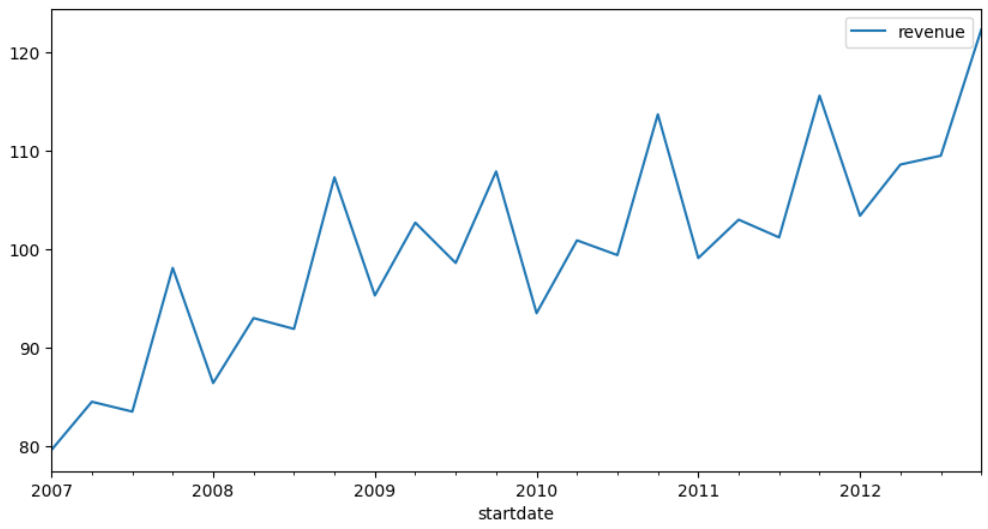

3. Make a forecast for next accounting year's sales using the most appropriate method. Explain why you chose this method.
4. Make a plot including the forecast for the next accounting year.
5. In which quarter will sales exceed $150 billion for the first time? [2018-10-01]

In [ ]:
dfwalmart = pd.DataFrame(data={
    'startdate': ['2007/01/01', '2007/04/01', '2007/07/01', '2007/10/01', '2008/01/01', '2008/04/01', '2008/07/01', '2008/10/01','2009/01/01', '2009/04/01', '2009/07/01', '2009/10/01','2010/01/01', '2010/04/01', '2010/07/01', '2010/10/01','2011/01/01', '2011/04/01', '2011/07/01', '2011/10/01','2012/01/01', '2012/04/01', '2012/07/01', '2012/10/01'],
    'quarter': ['2007-1','2007-2','2007-3','2007-4','2008-1','2008-2','2008-3','2008-4','2009-1','2009-2','2009-3','2009-4','2010-1','2010-2','2010-3','2010-4','2011-1','2011-2','2011-3','2011-4','2012-1','2011-2','2011-3','2011-4'],
    'revenue': [79.6,84.5,83.5,98.1,86.4,93,91.9,107.3,95.3,102.7,98.6,107.9,93.5,100.9,99.4,113.7,99.1,103,101.2,115.6,103.4,108.6,109.5,122.3]
})

dfwalmart.head()

,startdate,quarter,revenue
0,2007/01/01,2007-1,79.6
1,2007/04/01,2007-2,84.5
2,2007/07/01,2007-3,83.5
3,2007/10/01,2007-4,98.1
4,2008/01/01,2008-1,86.4


In [8]:
# 1. Convert the “startdate” to the datatype datetime.

dfwalmart.set_index('startdate')
dfwalmart.index = pd.DatetimeIndex(dfwalmart.startdate, freq='QS')

<Axes: xlabel='startdate'>

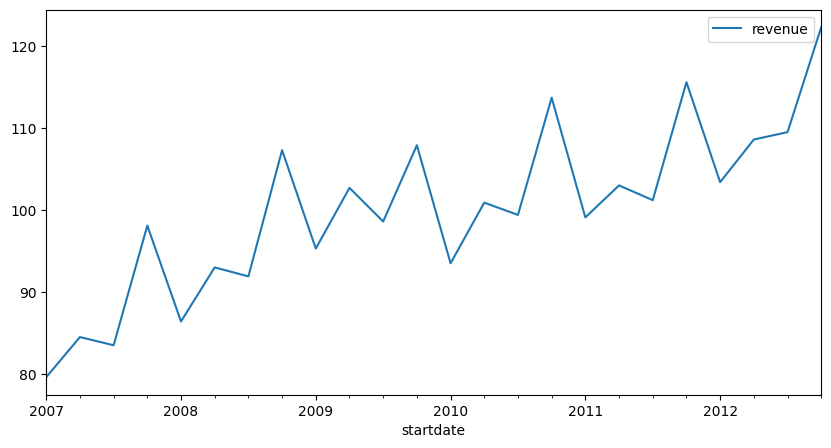

In [9]:
# 2. Create the plot below.
dfwalmart.plot(y='revenue', figsize=(10, 5))

In [12]:
dfwalmart.tail()

,startdate,quarter,revenue
startdate,,,
2011-10-01,2011/10/01,2011-4,115.6
2012-01-01,2012/01/01,2012-1,103.4
2012-04-01,2012/04/01,2011-2,108.6
2012-07-01,2012/07/01,2011-3,109.5
2012-10-01,2012/10/01,2011-4,122.3


In [18]:
# 3. Make a forecast for next accounting year's sales using the most appropriate method. Explain why you chose this method.

# TES => trend zichtbaar, en seasonal

# train = dfwalmart['revenue'][:'2012-10-01']
data_tes = ExponentialSmoothing(dfwalmart['revenue'], trend="add", seasonal="add", seasonal_periods=12, freq='QS').fit()
data_tes_fcast = data_tes.forecast(12)


<Axes: xlabel='startdate'>

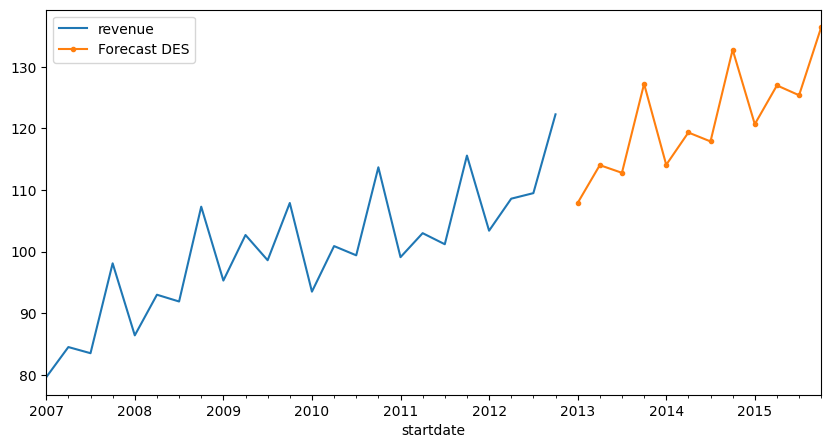

In [19]:
# 4.Make a plot including the forecast for the next accounting year.

dfwalmart['revenue'].plot(legend=True, figsize=(10, 5))
data_tes_fcast.plot(marker='.', legend=True, label="Forecast DES")

In [ ]:
# 5. In which quarter will sales exceed $150 billion for the first time?
